In [1]:
import numpy as np
import matplotlib.pyplot as plt

angles_deg = [20.0, 40.0, 60.0, 80.0]

branch_time = 0.25
total_time = 1.0

stem_length = 0.25
branch_length = 0.50

sigma_0 = 0.05
stabilizing_gain = 2.5

In [3]:
def smooth_progress(u):
    """Progress, first derivative, and second derivative."""
    s = 10 * u**3 - 15 * u**4 + 6 * u**5
    ds = 30 * u**2 - 60 * u**3 + 30 * u**4
    dds = 60 * u - 180 * u**2 + 120 * u**3
    return s, ds, dds


def expert_trajectory_2d(times, angle_deg, mode):
    """
    Return position, velocity, and acceleration, each shaped (N, 2).

    mode = +1: upper branch
    mode = -1: lower branch
    angle_deg: total spatial angle between the two branches
    """
    times = np.asarray(times, dtype=np.float64).reshape(-1)

    if mode not in (-1, +1):
        raise ValueError("mode must be -1 or +1")
    if not 0 < angle_deg < 180:
        raise ValueError("angle_deg must be between 0 and 180")
    if np.any((times < 0) | (times > total_time)):
        raise ValueError("Times must lie within [0, total_time]")

    positions = np.zeros((len(times), 2))
    velocities = np.zeros_like(positions)
    accelerations = np.zeros_like(positions)

    # Shared horizontal path.
    stem_mask = times <= branch_time
    u = times[stem_mask] / branch_time
    s, ds, dds = smooth_progress(u)

    positions[stem_mask, 0] = stem_length * s
    velocities[stem_mask, 0] = stem_length / branch_time * ds
    accelerations[stem_mask, 0] = (
        stem_length / branch_time**2 * dds
    )

    # Rotate the same branch motion by +/- half of the opening angle.
    branch_mask = ~stem_mask
    duration = total_time - branch_time
    u = (times[branch_mask] - branch_time) / duration
    s, ds, dds = smooth_progress(u)

    half_angle = np.deg2rad(angle_deg / 2)
    direction = np.array([
        np.cos(half_angle),
        mode * np.sin(half_angle),
    ])
    branch_point = np.array([stem_length, 0.0])

    positions[branch_mask] = (
        branch_point
        + branch_length * s[:, None] * direction
    )
    velocities[branch_mask] = (
        branch_length / duration * ds[:, None] * direction
    )
    accelerations[branch_mask] = (
        branch_length / duration**2 * dds[:, None] * direction
    )

    return positions, velocities, accelerations

  Angle     Length    Max speed    Max accel
---------------------------------------------
    20°   0.750000     1.875000    23.093821
    40°   0.750000     1.875000    23.093821
    60°   0.750000     1.875000    23.093821
    80°   0.750000     1.875000    23.093821


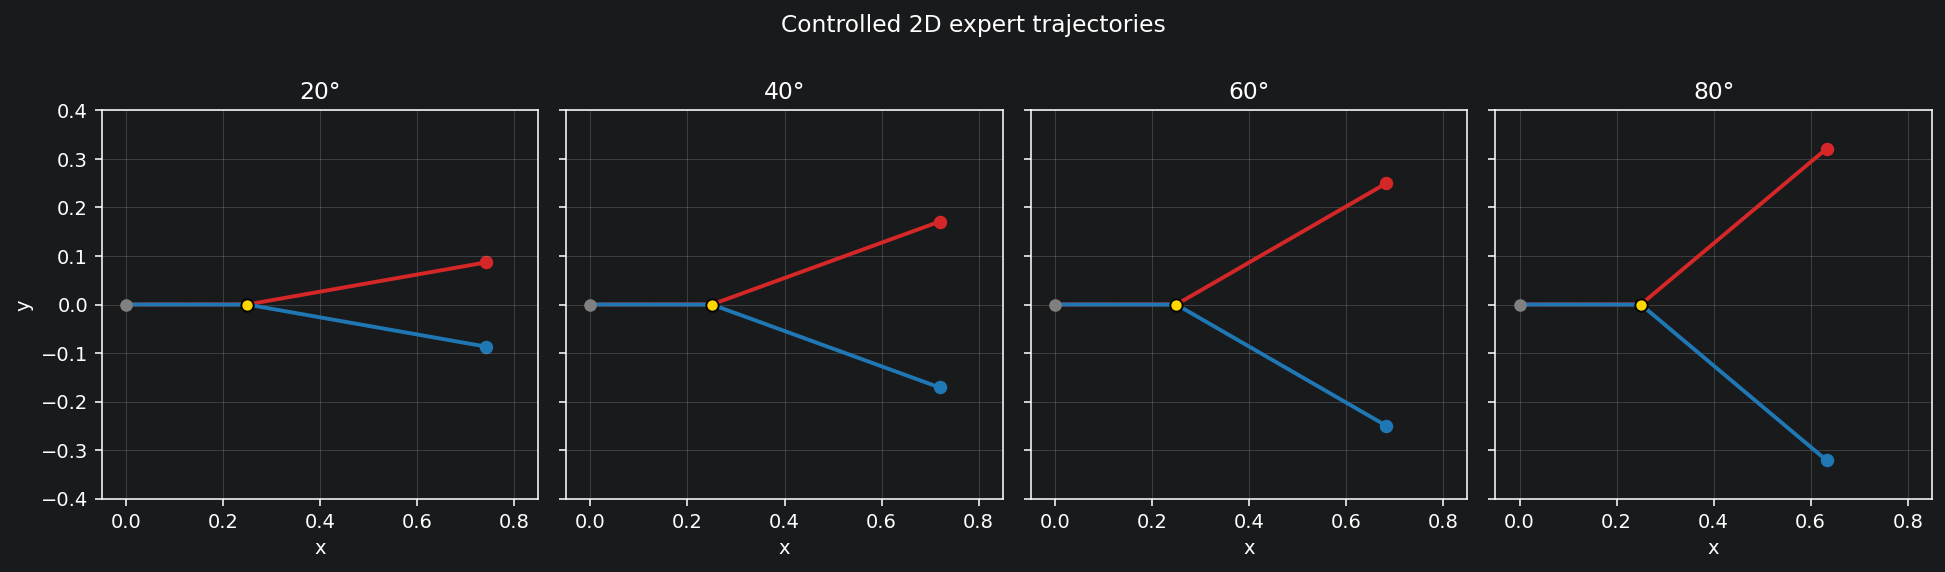


Checks passed: equal lengths and matching speed/acceleration magnitudes.


In [4]:
times = np.linspace(0.0, total_time, 2001)

fig, axes = plt.subplots(
    1, 4,
    figsize=(14, 4),
    dpi=140,
    sharex=True,
    sharey=True,
)

reference_speed = None
reference_acceleration = None

print(
    f"{'Angle':>7} "
    f"{'Length':>10} "
    f"{'Max speed':>12} "
    f"{'Max accel':>12}"
)
print("-" * 45)

for ax, angle in zip(axes, angles_deg):
    for mode, color in [(+1, "tab:red"), (-1, "tab:blue")]:
        positions, velocities, accelerations = expert_trajectory_2d(
            times, angle, mode
        )

        ax.plot(
            positions[:, 0],
            positions[:, 1],
            color=color,
            linewidth=2,
        )
        ax.scatter(
            positions[-1, 0],
            positions[-1, 1],
            color=color,
            s=35,
        )

    # Both branches have identical speed and acceleration magnitudes.
    speed = np.linalg.norm(velocities, axis=1)
    acceleration = np.linalg.norm(accelerations, axis=1)

    # Polygonal path length from densely sampled positions.
    length = np.linalg.norm(
        np.diff(positions, axis=0), axis=1
    ).sum()

    if reference_speed is None:
        reference_speed = speed.copy()
        reference_acceleration = acceleration.copy()
    else:
        np.testing.assert_allclose(
            speed, reference_speed, rtol=1e-10, atol=1e-10
        )
        np.testing.assert_allclose(
            acceleration,
            reference_acceleration,
            rtol=1e-10,
            atol=1e-10,
        )

    np.testing.assert_allclose(
        length, stem_length + branch_length, atol=1e-10
    )

    print(
        f"{angle:>6.0f}° "
        f"{length:>10.6f} "
        f"{speed.max():>12.6f} "
        f"{acceleration.max():>12.6f}"
    )

    ax.scatter(0, 0, color="gray", s=30, zorder=3)
    ax.scatter(
        stem_length, 0,
        color="gold", edgecolor="black",
        s=40, zorder=3,
    )

    ax.set_title(f"{angle:.0f}°")
    ax.set_xlabel("x")
    ax.set_xlim(-0.05, 0.85)
    ax.set_ylim(-0.4, 0.4)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(alpha=0.25)

axes[0].set_ylabel("y")
fig.suptitle("Controlled 2D expert trajectories")
plt.tight_layout()
plt.show()

print("\nChecks passed: equal lengths and matching speed/acceleration magnitudes.")

In [5]:
def generate_flow_matching_data_2d(
    angle_deg,
    num_samples,
    seed,
):
    rng = np.random.default_rng(seed)

    times = rng.uniform(0.0, total_time, size=num_samples)
    modes = rng.choice([-1, +1], size=num_samples)

    expert_positions = np.empty((num_samples, 2))
    expert_velocities = np.empty((num_samples, 2))

    for mode in [-1, +1]:
        mask = modes == mode

        positions, velocities, _ = expert_trajectory_2d(
            times[mask],
            angle_deg,
            mode,
        )

        expert_positions[mask] = positions
        expert_velocities[mask] = velocities

    # Isotropic Gaussian noise: equal scale along x and y.
    sigma_t = sigma_0 * np.exp(-stabilizing_gain * times)
    noise = rng.standard_normal((num_samples, 2))

    sampled_actions = (
        expert_positions + sigma_t[:, None] * noise
    )

    # Stabilizing conditional velocity target.
    target_velocities = (
        expert_velocities
        - stabilizing_gain
        * (sampled_actions - expert_positions)
    )

    inputs = np.column_stack([
        sampled_actions,
        times,
    ]).astype(np.float32)

    targets = target_velocities.astype(np.float32)

    assert inputs.shape == (num_samples, 3)
    assert targets.shape == (num_samples, 2)
    assert np.isfinite(inputs).all()
    assert np.isfinite(targets).all()

    return {
        "inputs": inputs,
        "targets": targets,
        "times": times,
        "modes": modes,
        "expert_positions": expert_positions,
        "sampled_actions": sampled_actions,
    }

Input shape: (20000, 3)
Target shape: (20000, 2)
Upper samples: 10007
Lower samples: 9993


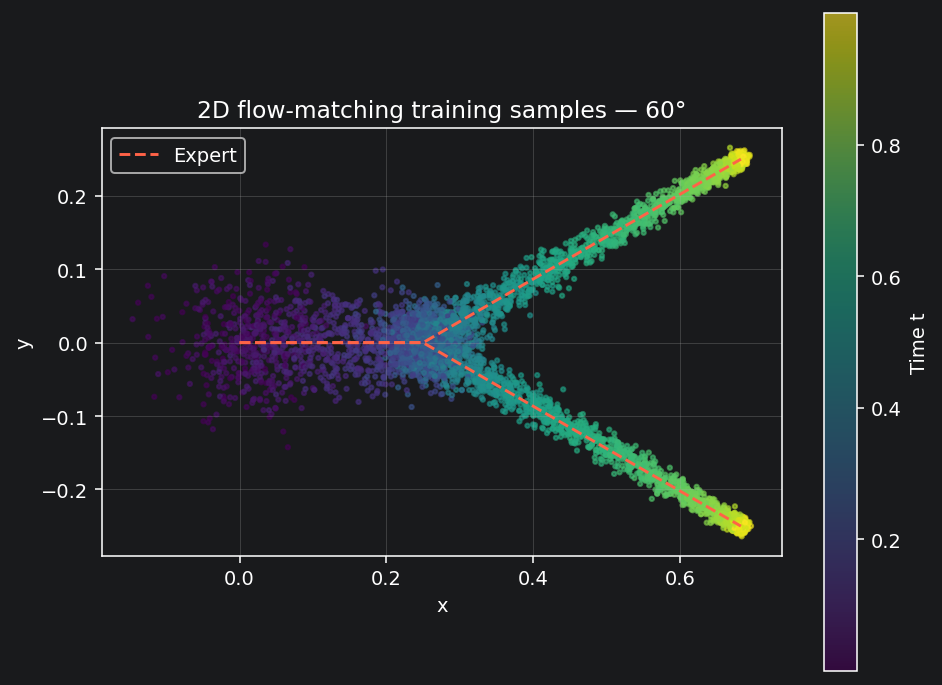

In [6]:
sanity_data_2d = generate_flow_matching_data_2d(
    angle_deg=60.0,
    num_samples=20_000,
    seed=0,
)

print("Input shape:", sanity_data_2d["inputs"].shape)
print("Target shape:", sanity_data_2d["targets"].shape)
print("Upper samples:", np.sum(sanity_data_2d["modes"] == +1))
print("Lower samples:", np.sum(sanity_data_2d["modes"] == -1))

indices = np.random.default_rng(1).choice(
    20_000, size=5000, replace=False
)

fig, ax = plt.subplots(figsize=(7, 5), dpi=140)

scatter = ax.scatter(
    sanity_data_2d["sampled_actions"][indices, 0],
    sanity_data_2d["sampled_actions"][indices, 1],
    c=sanity_data_2d["times"][indices],
    cmap="viridis",
    s=5,
    alpha=0.6,
)

expert_times = np.linspace(0.0, total_time, 500)

for mode in [-1, +1]:
    positions, _, _ = expert_trajectory_2d(
        expert_times, 60.0, mode
    )

    ax.plot(
        positions[:, 0],
        positions[:, 1],
        color="tomato",
        linestyle="--",
        linewidth=1.5,
        label="Expert" if mode == +1 else None,
    )

fig.colorbar(scatter, ax=ax, label="Time t")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("2D flow-matching training samples — 60°")
ax.set_aspect("equal", adjustable="box")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
import random
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
print("Device:", device)


def set_seed_2d(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


class VelocityMLP2D(nn.Module):
    """Input: (x, y, t). Output: (vx, vy)."""

    def __init__(self):
        super().__init__()

        # Fixed normalization, identical for every angle.
        self.register_buffer(
            "input_center",
            torch.tensor([0.375, 0.0, total_time / 2],
                         dtype=torch.float32),
        )
        self.register_buffer(
            "input_scale",
            torch.tensor([0.5, 0.5, total_time / 2],
                         dtype=torch.float32),
        )

        layers = []
        input_dim = 3

        for _ in range(4):
            layers.extend([
                nn.Linear(input_dim, 128),
                nn.SiLU(),
            ])
            input_dim = 128

        layers.append(nn.Linear(128, 2))
        self.network = nn.Sequential(*layers)

    def forward(self, inputs):
        normalized = (
            inputs - self.input_center
        ) / self.input_scale
        return self.network(normalized)

Device: cuda


In [8]:
def train_velocity_model_2d(
    angle_deg,
    seed=0,
    num_epochs=50,
    num_train_samples=100_000,
    num_validation_samples=20_000,
    batch_size=2048,
    learning_rate=1e-3,
):
    set_seed_2d(seed)

    train_data = generate_flow_matching_data_2d(
        angle_deg, num_train_samples, seed
    )
    val_data = generate_flow_matching_data_2d(
        angle_deg, num_validation_samples, seed + 10_000
    )

    train_dataset = TensorDataset(
        torch.from_numpy(train_data["inputs"]),
        torch.from_numpy(train_data["targets"]),
    )
    val_dataset = TensorDataset(
        torch.from_numpy(val_data["inputs"]),
        torch.from_numpy(val_data["targets"]),
    )

    generator = torch.Generator().manual_seed(seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=generator,
        num_workers=0,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
    )

    # Explicit float32 avoids interference from an earlier
    # notebook cell that may have selected torch.double.
    model = VelocityMLP2D().to(
        device=device, dtype=torch.float32
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=1e-6,
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=num_epochs
    )
    loss_function = nn.MSELoss()

    history = {"train_loss": [], "validation_loss": []}
    best_loss = float("inf")
    best_state = None
    best_epoch = None

    for epoch in range(1, num_epochs + 1):
        model.train()
        train_sum = 0.0

        for inputs, targets in train_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            optimizer.zero_grad(set_to_none=True)
            loss = loss_function(model(inputs), targets)

            if not torch.isfinite(loss):
                raise RuntimeError("Non-finite training loss")

            loss.backward()
            optimizer.step()

            train_sum += loss.item() * len(inputs)

        model.eval()
        val_sum = 0.0

        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs = inputs.to(device)
                targets = targets.to(device)

                loss = loss_function(model(inputs), targets)

                if not torch.isfinite(loss):
                    raise RuntimeError("Non-finite validation loss")

                val_sum += loss.item() * len(inputs)

        train_loss = train_sum / len(train_dataset)
        val_loss = val_sum / len(val_dataset)

        history["train_loss"].append(train_loss)
        history["validation_loss"].append(val_loss)

        if val_loss < best_loss:
            best_loss = val_loss
            best_epoch = epoch
            best_state = {
                name: tensor.detach().cpu().clone()
                for name, tensor in model.state_dict().items()
            }

        scheduler.step()

        if epoch == 1 or epoch % 5 == 0:
            print(
                f"Angle {angle_deg:.0f}° | "
                f"Epoch {epoch:>3}/{num_epochs} | "
                f"train={train_loss:.6f} | "
                f"validation={val_loss:.6f}"
            )

    model.load_state_dict(best_state)
    model.eval()

    history["best_epoch"] = best_epoch
    history["best_validation_loss"] = best_loss

    print(
        f"\nBest validation loss: {best_loss:.6f} "
        f"(epoch {best_epoch})"
    )
    return model, history

Angle 60° | Epoch   1/50 | train=0.197427 | validation=0.153408
Angle 60° | Epoch   5/50 | train=0.078585 | validation=0.052044
Angle 60° | Epoch  10/50 | train=0.006365 | validation=0.006377
Angle 60° | Epoch  15/50 | train=0.005225 | validation=0.005218
Angle 60° | Epoch  20/50 | train=0.004915 | validation=0.004820
Angle 60° | Epoch  25/50 | train=0.004490 | validation=0.004428
Angle 60° | Epoch  30/50 | train=0.004196 | validation=0.004124
Angle 60° | Epoch  35/50 | train=0.003967 | validation=0.003916
Angle 60° | Epoch  40/50 | train=0.003823 | validation=0.003789
Angle 60° | Epoch  45/50 | train=0.003752 | validation=0.003706
Angle 60° | Epoch  50/50 | train=0.003735 | validation=0.003690

Best validation loss: 0.003690 (epoch 50)


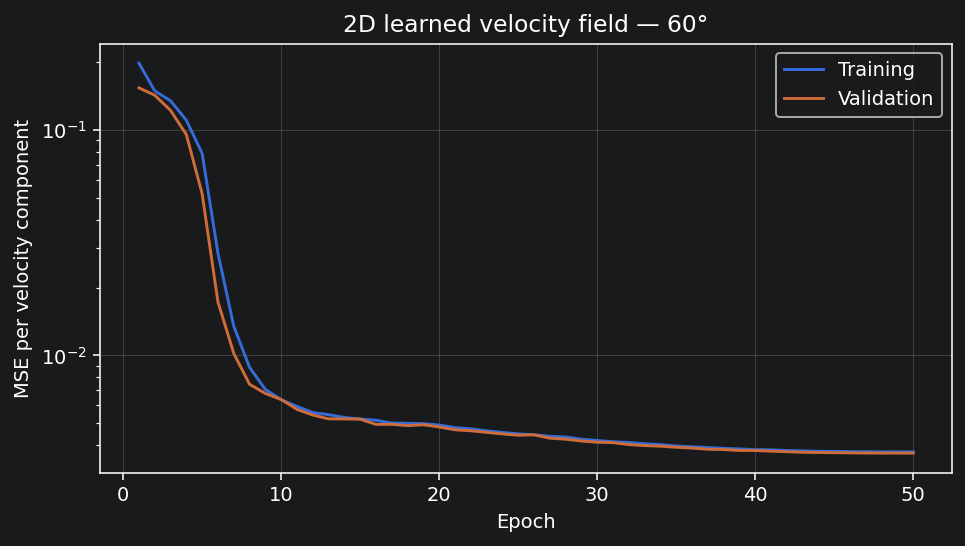

In [21]:
model_2d_60, history_2d_60 = train_velocity_model_2d(
    angle_deg=60.0,
    seed=0,
)

epochs = np.arange(
    1, len(history_2d_60["train_loss"]) + 1
)

plt.figure(figsize=(7, 4), dpi=140)
plt.plot(
    epochs,
    history_2d_60["train_loss"],
    label="Training",
)
plt.plot(
    epochs,
    history_2d_60["validation_loss"],
    label="Validation",
)
plt.xlabel("Epoch")
plt.ylabel("MSE per velocity component")
plt.title("2D learned velocity field — 60°")
plt.yscale("log")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
import copy

# Evaluate a float64 copy without changing the trained model.
evaluation_model_60 = copy.deepcopy(model_2d_60).to(
    device=device, dtype=torch.float64
)
evaluation_model_60.eval()


def analytic_velocity_2d(actions, time, angle_deg):
    """actions: (N, 2); return marginal velocity: (N, 2)."""
    time = float(np.clip(time, 0.0, total_time))

    positions = []
    velocities = []

    for mode in [-1, +1]:
        p, v, _ = expert_trajectory_2d(
            [time], angle_deg, mode
        )
        positions.append(p[0])
        velocities.append(v[0])

    positions = np.stack(positions)      # (2, 2)
    velocities = np.stack(velocities)    # (2, 2)

    differences = actions[:, None, :] - positions[None, :, :]
    variance = sigma_0**2 * np.exp(
        -2 * stabilizing_gain * time
    )

    # Equal priors and equal covariance: common factors cancel.
    log_weights = -np.sum(differences**2, axis=2) / (2 * variance)
    log_weights -= log_weights.max(axis=1, keepdims=True)

    weights = np.exp(log_weights)
    weights /= weights.sum(axis=1, keepdims=True)

    conditional_velocities = (
        velocities[None, :, :]
        - stabilizing_gain * differences
    )

    return np.sum(
        weights[:, :, None] * conditional_velocities,
        axis=1,
    )


@torch.no_grad()
def learned_velocity_2d(actions, time):
    inputs = np.column_stack([
        actions,
        np.full(len(actions), time),
    ])
    inputs = torch.as_tensor(
        inputs, dtype=torch.float64, device=device
    )
    return evaluation_model_60(inputs).cpu().numpy()

In [28]:
def integrate_velocity_2d(
    velocity_function,
    initial_actions,
    num_steps=1000,
    num_saved_paths=100,
):
    actions = np.array(initial_actions, dtype=np.float64, copy=True)
    dt = total_time / num_steps

    # Save only the first 100 paths for plotting.
    paths = [actions[:num_saved_paths].copy()]

    for step in range(num_steps):
        t = step * dt

        k1 = velocity_function(actions, t)
        k2 = velocity_function(actions + dt * k1 / 2, t + dt / 2)
        k3 = velocity_function(actions + dt * k2 / 2, t + dt / 2)
        k4 = velocity_function(
            actions + dt * k3, min(t + dt, total_time)
        )

        actions += dt / 6 * (k1 + 2*k2 + 2*k3 + k4)

        if not np.isfinite(actions).all():
            raise RuntimeError(f"Non-finite trajectory at step {step}")

        paths.append(actions[:num_saved_paths].copy())

    # Shape: (saved samples, time points, 2).
    return actions, np.stack(paths, axis=1)


def endpoint_metrics_2d(final_actions, angle_deg):
    goals = np.stack([
        expert_trajectory_2d([total_time], angle_deg, mode)[0][0]
        for mode in [-1, +1]
    ])

    # Euclidean distance to the nearest valid goal.
    distances = np.linalg.norm(
        final_actions[:, None, :] - goals[None, :, :],
        axis=2,
    )
    errors = distances.min(axis=1)

    return {
        "success_001": np.mean(errors <= 0.01),
        "success_005": np.mean(errors <= 0.05),
        "mean_error": errors.mean(),
        "p95_error": np.quantile(errors, 0.95),
        "max_error": errors.max(),
        "upper_fraction": np.mean(distances.argmin(axis=1) == 1),
        "errors": errors,
    }


# Reuse exactly the same initial positions for both methods.
test_initial_2d = np.random.default_rng(0).normal(
    loc=0.0, scale=sigma_0, size=(1000, 2)
)

analytic_final_60, analytic_paths_60 = integrate_velocity_2d(
    lambda actions, time: analytic_velocity_2d(actions, time, 60.0),
    test_initial_2d,
)

learned_final_60, learned_paths_60 = integrate_velocity_2d(
    learned_velocity_2d,
    test_initial_2d,
)

results_2d_60 = {
    "Analytic": endpoint_metrics_2d(analytic_final_60, 60.0),
    "Learned": endpoint_metrics_2d(learned_final_60, 60.0),
}

print(
    f"{'Method':>10} {'Succ@.01':>10} {'Succ@.05':>10} "
    f"{'Mean err':>10} {'P95 err':>10} {'Max err':>10} "
    f"{'Upper %':>9}"
)

for name, result in results_2d_60.items():
    print(
        f"{name:>10} "
        f"{result['success_001']:>10.2%} "
        f"{result['success_005']:>10.2%} "
        f"{result['mean_error']:>10.6f} "
        f"{result['p95_error']:>10.6f} "
        f"{result['max_error']:>10.6f} "
        f"{result['upper_fraction']:>9.2%}"
    )

    Method   Succ@.01   Succ@.05   Mean err    P95 err    Max err   Upper %
  Analytic     95.20%    100.00%   0.005181   0.009945   0.016075    48.20%
   Learned     39.60%     78.30%   0.035695   0.147120   0.250273    50.10%


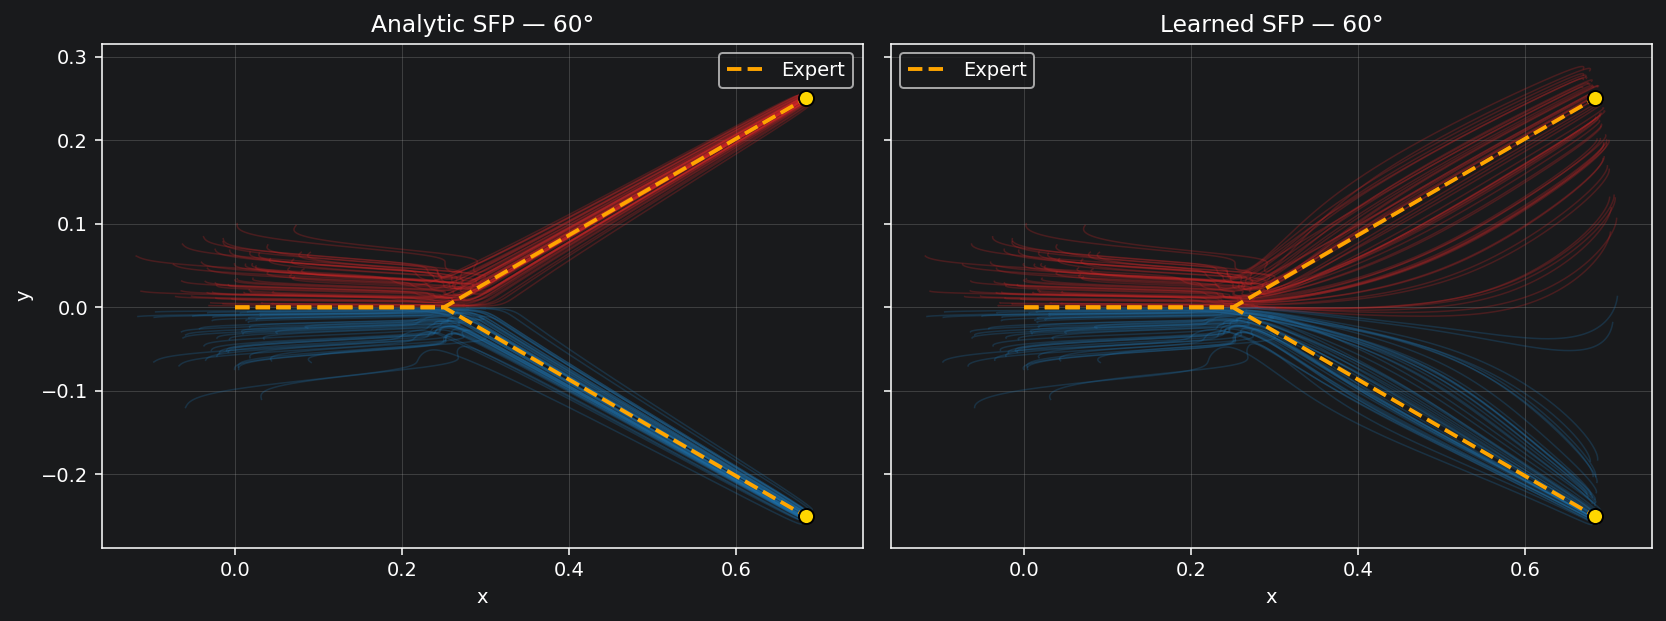

In [29]:
fig, axes = plt.subplots(
    1, 2, figsize=(12, 5), dpi=140,
    sharex=True, sharey=True,
)

expert_times = np.linspace(0.0, total_time, 500)

for ax, name, paths in [
    (axes[0], "Analytic SFP — 60°", analytic_paths_60),
    (axes[1], "Learned SFP — 60°", learned_paths_60),
]:
    for initial, path in zip(test_initial_2d, paths):
        color = "tab:red" if initial[1] > 0 else "tab:blue"
        ax.plot(
            path[:, 0], path[:, 1],
            color=color, alpha=0.25, linewidth=0.8,
        )

    for mode in [-1, +1]:
        expert, _, _ = expert_trajectory_2d(
            expert_times, 60.0, mode
        )
        ax.plot(
            expert[:, 0], expert[:, 1],
            color="orange", linestyle="--", linewidth=2,
            label="Expert" if mode == +1 else None,
        )
        ax.scatter(
            expert[-1, 0], expert[-1, 1],
            color="gold", edgecolor="black",
            s=60, zorder=5,
        )

    ax.set_title(name)
    ax.set_xlabel("x")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(alpha=0.25)
    ax.legend()

axes[0].set_ylabel("y")
plt.tight_layout()
plt.show()

In [30]:
# Check numerical sensitivity without retraining.
step_check = {}

for name, velocity_function, previous_final in [
    (
        "Analytic",
        lambda actions, time: analytic_velocity_2d(
            actions, time, 60.0
        ),
        analytic_final_60,
    ),
    (
        "Learned",
        learned_velocity_2d,
        learned_final_60,
    ),
]:
    refined_final, _ = integrate_velocity_2d(
        velocity_function,
        test_initial_2d,
        num_steps=2000,
        num_saved_paths=0,
    )

    endpoint_change = np.linalg.norm(
        refined_final - previous_final,
        axis=1,
    )

    old_metrics = endpoint_metrics_2d(previous_final, 60.0)
    new_metrics = endpoint_metrics_2d(refined_final, 60.0)

    classification_changes = np.sum(
        (old_metrics["errors"] <= 0.05)
        != (new_metrics["errors"] <= 0.05)
    )

    step_check[name] = {
        "final_actions": refined_final,
        "metrics": new_metrics,
        "endpoint_change": endpoint_change,
    }

    print(f"\n{name}: 1000 → 2000 RK4 steps")
    print(
        f"Mean endpoint change: {endpoint_change.mean():.8f}"
    )
    print(
        f"Max endpoint change:  {endpoint_change.max():.8f}"
    )
    print(
        f"Success@0.01: "
        f"{old_metrics['success_001']:.2%} → "
        f"{new_metrics['success_001']:.2%}"
    )
    print(
        f"Success@0.05: "
        f"{old_metrics['success_005']:.2%} → "
        f"{new_metrics['success_005']:.2%}"
    )
    print(
        f"Mean error: "
        f"{old_metrics['mean_error']:.6f} → "
        f"{new_metrics['mean_error']:.6f}"
    )
    print(
        f"Changed success/failure labels @0.05: "
        f"{classification_changes}"
    )


Analytic: 1000 → 2000 RK4 steps
Mean endpoint change: 0.00000000
Max endpoint change:  0.00000000
Success@0.01: 95.20% → 95.20%
Success@0.05: 100.00% → 100.00%
Mean error: 0.005181 → 0.005181
Changed success/failure labels @0.05: 0

Learned: 1000 → 2000 RK4 steps
Mean endpoint change: 0.00000000
Max endpoint change:  0.00000000
Success@0.01: 39.60% → 39.60%
Success@0.05: 78.30% → 78.30%
Mean error: 0.035695 → 0.035695
Changed success/failure labels @0.05: 0


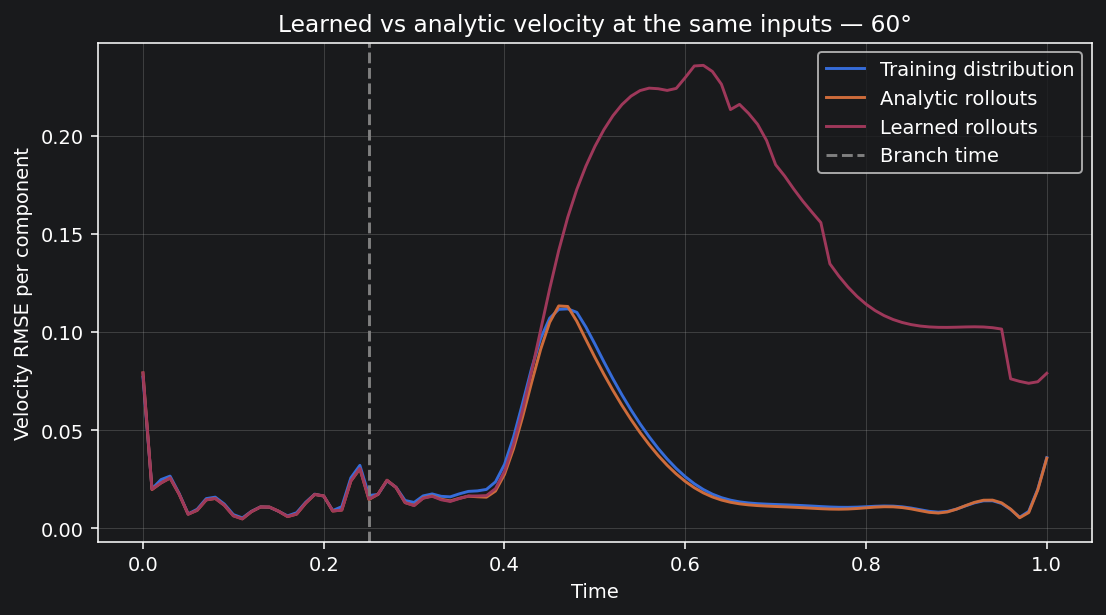

Training distribution: peak RMSE=0.111756, time=0.47
Analytic rollouts: peak RMSE=0.113245, time=0.46
Learned rollouts: peak RMSE=0.235847, time=0.62


In [31]:
# Diagnose velocity errors at matching positions and times.
# Uses the saved first 100 trajectories from each method.
diagnostic_indices = np.linspace(
    0, analytic_paths_60.shape[1] - 1, 101
).round().astype(int)

diagnostic_times = (
    diagnostic_indices
    / (analytic_paths_60.shape[1] - 1)
    * total_time
)

velocity_error_curves = {}
diagnostic_rng = np.random.default_rng(12345)

# Fresh samples from the known training marginal distribution.
num_probe_samples = 1000
probe_modes = diagnostic_rng.choice(
    [-1, +1], size=num_probe_samples
)
probe_noise = diagnostic_rng.standard_normal(
    (num_probe_samples, 2)
)

for source in [
    "Training distribution",
    "Analytic rollouts",
    "Learned rollouts",
]:
    rmse_values = []

    for index, time in zip(
        diagnostic_indices, diagnostic_times
    ):
        if source == "Training distribution":
            centers = np.empty((num_probe_samples, 2))

            for mode in [-1, +1]:
                position, _, _ = expert_trajectory_2d(
                    [time], 60.0, mode
                )
                centers[probe_modes == mode] = position[0]

            actions = (
                centers
                + sigma_0
                * np.exp(-stabilizing_gain * time)
                * probe_noise
            )

        elif source == "Analytic rollouts":
            actions = analytic_paths_60[:, index, :]

        else:
            actions = learned_paths_60[:, index, :]

        exact_velocity = analytic_velocity_2d(
            actions, time, 60.0
        )
        predicted_velocity = learned_velocity_2d(
            actions, time
        )

        # RMSE averaged over samples and the two components.
        rmse = np.sqrt(np.mean(
            (predicted_velocity - exact_velocity) ** 2
        ))
        rmse_values.append(rmse)

    velocity_error_curves[source] = np.array(rmse_values)


plt.figure(figsize=(8, 4.5), dpi=140)

for source, errors in velocity_error_curves.items():
    plt.plot(
        diagnostic_times,
        errors,
        label=source,
    )

plt.axvline(
    branch_time,
    color="gray",
    linestyle="--",
    label="Branch time",
)
plt.xlabel("Time")
plt.ylabel("Velocity RMSE per component")
plt.title("Learned vs analytic velocity at the same inputs — 60°")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

# Print the largest observed discrepancy for each probe set.
for source, errors in velocity_error_curves.items():
    peak_index = np.argmax(errors)
    print(
        f"{source}: "
        f"peak RMSE={errors[peak_index]:.6f}, "
        f"time={diagnostic_times[peak_index]:.2f}"
    )

In [32]:
models_2d = {60.0: model_2d_60}
histories_2d = {60.0: history_2d_60}

for angle in [20.0, 40.0, 80.0]:
    print(f"\nTraining {angle:.0f}°")

    model, history = train_velocity_model_2d(
        angle_deg=angle,
        seed=0,
        num_epochs=50,
        num_train_samples=100_000,
        num_validation_samples=20_000,
        batch_size=2048,
        learning_rate=1e-3,
    )

    models_2d[angle] = model
    histories_2d[angle] = history


Training 20°
Angle 20° | Epoch   1/50 | train=0.174591 | validation=0.135985
Angle 20° | Epoch   5/50 | train=0.073519 | validation=0.064190
Angle 20° | Epoch  10/50 | train=0.006048 | validation=0.005641
Angle 20° | Epoch  15/50 | train=0.003487 | validation=0.003410
Angle 20° | Epoch  20/50 | train=0.002705 | validation=0.002746
Angle 20° | Epoch  25/50 | train=0.002476 | validation=0.002599
Angle 20° | Epoch  30/50 | train=0.002419 | validation=0.002395
Angle 20° | Epoch  35/50 | train=0.002367 | validation=0.002365
Angle 20° | Epoch  40/50 | train=0.002336 | validation=0.002347
Angle 20° | Epoch  45/50 | train=0.002326 | validation=0.002346
Angle 20° | Epoch  50/50 | train=0.002324 | validation=0.002340

Best validation loss: 0.002340 (epoch 50)

Training 40°
Angle 40° | Epoch   1/50 | train=0.186195 | validation=0.147186
Angle 40° | Epoch   5/50 | train=0.071907 | validation=0.052928
Angle 40° | Epoch  10/50 | train=0.005411 | validation=0.005513
Angle 40° | Epoch  15/50 | train=

In [33]:
def make_learned_velocity_function(model):
    evaluation_model = copy.deepcopy(model).to(
        device=device, dtype=torch.float64
    )
    evaluation_model.eval()

    @torch.no_grad()
    def velocity(actions, time):
        inputs = np.column_stack([
            actions,
            np.full(len(actions), time),
        ])
        inputs = torch.as_tensor(
            inputs,
            dtype=torch.float64,
            device=device,
        )
        return evaluation_model(inputs).cpu().numpy()

    return velocity


comparison_results_2d = {}
comparison_paths_2d = {}

for angle in angles_deg:
    print(f"Evaluating {angle:.0f}°...")

    learned_function = make_learned_velocity_function(
        models_2d[angle]
    )

    functions = {
        "Analytic": lambda actions, time, angle=angle:
            analytic_velocity_2d(actions, time, angle),
        "Learned": learned_function,
    }

    for method, velocity_function in functions.items():
        final_actions, paths = integrate_velocity_2d(
            velocity_function,
            test_initial_2d,
            num_steps=1000,
            num_saved_paths=100,
        )

        comparison_results_2d[(angle, method)] = (
            endpoint_metrics_2d(final_actions, angle)
        )
        comparison_paths_2d[(angle, method)] = paths

print(
    f"\n{'Angle':>7} {'Method':>10} "
    f"{'Succ@.01':>10} {'Succ@.05':>10} "
    f"{'Mean err':>10} {'P95 err':>10} {'Upper %':>9}"
)

for angle in angles_deg:
    for method in ["Analytic", "Learned"]:
        result = comparison_results_2d[(angle, method)]

        print(
            f"{angle:>6.0f}° {method:>10} "
            f"{result['success_001']:>10.2%} "
            f"{result['success_005']:>10.2%} "
            f"{result['mean_error']:>10.6f} "
            f"{result['p95_error']:>10.6f} "
            f"{result['upper_fraction']:>9.2%}"
        )

Evaluating 20°...
Evaluating 40°...
Evaluating 60°...
Evaluating 80°...

  Angle     Method   Succ@.01   Succ@.05   Mean err    P95 err   Upper %
    20°   Analytic     95.20%    100.00%   0.005181   0.009945    48.20%
    20°    Learned      9.10%     55.40%   0.047811   0.086466    45.70%
    40°   Analytic     95.20%    100.00%   0.005181   0.009945    48.20%
    40°    Learned      4.60%     27.80%   0.089298   0.167023    46.10%
    60°   Analytic     95.20%    100.00%   0.005181   0.009945    48.20%
    60°    Learned     39.60%     78.30%   0.035695   0.147120    50.10%
    80°   Analytic     95.20%    100.00%   0.005181   0.009945    48.20%
    80°    Learned     27.00%     57.20%   0.071200   0.263804    45.30%


In [38]:
# Preserve completed runs if this cell is interrupted and rerun.
if "multiseed_results_2d" not in globals():
    multiseed_results_2d = {}

# Reuse the existing seed=0 results.
for angle in angles_deg:
    multiseed_results_2d[(angle, 0)] = {
        "metrics": comparison_results_2d[(angle, "Learned")],
        "best_validation_loss": histories_2d[angle][
            "best_validation_loss"
        ],
    }

for seed in [1, 2, 3, 4]:
    for angle in angles_deg:
        key = (angle, seed)

        if key in multiseed_results_2d:
            continue

        print(f"\nTraining angle={angle:.0f}°, seed={seed}")

        model, history = train_velocity_model_2d(
            angle_deg=angle,
            seed=seed,
            num_epochs=50,
            num_train_samples=100_000,
            num_validation_samples=20_000,
            batch_size=2048,
            learning_rate=1e-3,
        )

        velocity_function = make_learned_velocity_function(model)

        final_actions, _ = integrate_velocity_2d(
            velocity_function,
            test_initial_2d,
            num_steps=1000,
            num_saved_paths=0,
        )

        metrics = endpoint_metrics_2d(final_actions, angle)

        multiseed_results_2d[key] = {
            "metrics": metrics,
            "best_validation_loss": history["best_validation_loss"],
        }

        print(
            f"Completed: angle={angle:.0f}°, seed={seed}, "
            f"success@0.05={metrics['success_005']:.2%}, "
            f"mean error={metrics['mean_error']:.6f}"
        )

        del velocity_function, model


Training angle=40°, seed=1
Angle 40° | Epoch   1/50 | train=0.193333 | validation=0.149881
Angle 40° | Epoch   5/50 | train=0.081280 | validation=0.069849
Angle 40° | Epoch  10/50 | train=0.006261 | validation=0.005828
Angle 40° | Epoch  15/50 | train=0.004478 | validation=0.004520
Angle 40° | Epoch  20/50 | train=0.004126 | validation=0.004243
Angle 40° | Epoch  25/50 | train=0.003968 | validation=0.004180
Angle 40° | Epoch  30/50 | train=0.003873 | validation=0.004032
Angle 40° | Epoch  35/50 | train=0.003815 | validation=0.003932
Angle 40° | Epoch  40/50 | train=0.003772 | validation=0.003927
Angle 40° | Epoch  45/50 | train=0.003752 | validation=0.003898
Angle 40° | Epoch  50/50 | train=0.003747 | validation=0.003892

Best validation loss: 0.003891 (epoch 49)
Completed: angle=40°, seed=1, success@0.05=26.30%, mean error=0.092090

Training angle=60°, seed=1
Angle 60° | Epoch   1/50 | train=0.207546 | validation=0.153610
Angle 60° | Epoch   5/50 | train=0.080874 | validation=0.05861

KeyboardInterrupt: 

In [17]:
print(
    f"{'Angle':>7} "
    f"{'Success@.05 mean ± SD':>25} "
    f"{'Mean error mean ± SD':>25}"
)

for angle in angles_deg:
    successes = np.array([
        multiseed_results_2d[(angle, seed)]["metrics"]["success_005"]
        for seed in range(5)
    ])

    errors = np.array([
        multiseed_results_2d[(angle, seed)]["metrics"]["mean_error"]
        for seed in range(5)
    ])

    print(
        f"{angle:>6.0f}° "
        f"{100 * successes.mean():>9.2f}% ± "
        f"{100 * successes.std(ddof=1):.2f} pp "
        f"{errors.mean():>12.6f} ± "
        f"{errors.std(ddof=1):.6f}"
    )

    print(
        "        Success by seed:",
        ", ".join(f"{value:.1%}" for value in successes),
    )

  Angle     Success@.05 mean ± SD      Mean error mean ± SD
    20°     55.28% ± 0.77 pp     0.047859 ± 0.000247
        Success by seed: 55.4%, 54.5%, 54.8%, 56.5%, 55.2%
    40°     27.90% ± 1.30 pp     0.089380 ± 0.002445
        Success by seed: 27.8%, 26.3%, 27.0%, 29.3%, 29.1%
    60°     49.70% ± 31.88 pp     0.077942 ± 0.046200
        Success by seed: 78.3%, 19.9%, 38.7%, 88.7%, 22.9%
    80°     73.14% ± 24.13 pp     0.047354 ± 0.035722
        Success by seed: 57.2%, 99.7%, 49.2%, 98.6%, 61.0%


In [17]:
from pathlib import Path
import json

project_root = Path(
    "/home/matcho/projects/streaming-flow-policy"
)

if not (project_root / "pyproject.toml").exists():
    raise FileNotFoundError("请检查 project_root 是否指向项目根目录")

budget_output_dir = (
    project_root
    / "experiments"
    / "multimodal_paths"
    / "results_2d_budget_200"
)
budget_output_dir.mkdir(parents=True, exist_ok=True)

print("Results directory:", budget_output_dir)

# Save the existing 50-epoch summary for comparison.
baseline_file = budget_output_dir / "baseline_50_epochs.json"

if not baseline_file.exists():
    baseline_rows = []

    for angle in angles_deg:
        for seed in range(5):
            run = multiseed_results_2d[(angle, seed)]

            scalar_metrics = {
                name: float(value)
                for name, value in run["metrics"].items()
                if np.isscalar(value)
            }

            baseline_rows.append({
                "angle": float(angle),
                "seed": seed,
                "metrics": scalar_metrics,
                "best_validation_loss": float(
                    run["best_validation_loss"]
                ),
            })

    with baseline_file.open("w", encoding="utf-8") as file:
        json.dump(baseline_rows, file, indent=2)

Results directory: /home/matcho/projects/streaming-flow-policy/experiments/multimodal_paths/results_2d_budget_200


In [18]:
budget_results_2d = {}

for seed in range(5):
    for angle in angles_deg:
        run_name = f"angle_{angle:.0f}_seed_{seed}"
        summary_path = budget_output_dir / f"{run_name}.json"
        weights_path = budget_output_dir / f"{run_name}.pt"
        endpoints_path = budget_output_dir / f"{run_name}_endpoints.npz"

        # Completed runs can be resumed after a kernel restart.
        if (
            summary_path.exists()
            and weights_path.exists()
            and endpoints_path.exists()
        ):
            with summary_path.open("r", encoding="utf-8") as file:
                budget_results_2d[(angle, seed)] = json.load(file)

            print(f"Already completed: {run_name}")
            continue

        print(f"\nTraining {run_name}: 200 epochs")

        model, history = train_velocity_model_2d(
            angle_deg=angle,
            seed=seed,
            num_epochs=200,
            num_train_samples=100_000,
            num_validation_samples=20_000,
            batch_size=2048,
            learning_rate=1e-3,
        )

        velocity_function = make_learned_velocity_function(model)

        final_actions, _ = integrate_velocity_2d(
            velocity_function,
            test_initial_2d,
            num_steps=1000,
            num_saved_paths=0,
        )

        metrics = endpoint_metrics_2d(final_actions, angle)

        summary = {
            "angle": float(angle),
            "seed": seed,
            "num_epochs": 200,
            "best_epoch": int(history["best_epoch"]),
            "best_validation_loss": float(
                history["best_validation_loss"]
            ),
            "metrics": {
                name: float(value)
                for name, value in metrics.items()
                if np.isscalar(value)
            },
            "history": history,
            "config": {
                "num_train_samples": 100_000,
                "num_validation_samples": 20_000,
                "batch_size": 2048,
                "learning_rate": 1e-3,
                "sigma_0": sigma_0,
                "stabilizing_gain": stabilizing_gain,
                "branch_time": branch_time,
                "total_time": total_time,
                "stem_length": stem_length,
                "branch_length": branch_length,
                "ode_steps": 1000,
            },
        }

        torch.save(
            {
                name: tensor.detach().cpu().clone()
                for name, tensor in model.state_dict().items()
            },
            weights_path,
        )

        np.savez_compressed(
            endpoints_path,
            initial_actions=test_initial_2d,
            final_actions=final_actions,
            endpoint_errors=metrics["errors"],
        )

        # Write the completion summary last.
        with summary_path.open("w", encoding="utf-8") as file:
            json.dump(summary, file, indent=2)

        budget_results_2d[(angle, seed)] = summary

        print(
            f"Saved {run_name} | "
            f"best epoch={history['best_epoch']} | "
            f"success@0.05={metrics['success_005']:.2%}"
        )

        del velocity_function, model

Already completed: angle_20_seed_0
Already completed: angle_40_seed_0
Already completed: angle_60_seed_0
Already completed: angle_80_seed_0
Already completed: angle_20_seed_1
Already completed: angle_40_seed_1
Already completed: angle_60_seed_1
Already completed: angle_80_seed_1
Already completed: angle_20_seed_2
Already completed: angle_40_seed_2
Already completed: angle_60_seed_2
Already completed: angle_80_seed_2
Already completed: angle_20_seed_3
Already completed: angle_40_seed_3
Already completed: angle_60_seed_3
Already completed: angle_80_seed_3
Already completed: angle_20_seed_4
Already completed: angle_40_seed_4
Already completed: angle_60_seed_4
Already completed: angle_80_seed_4


In [19]:
with baseline_file.open("r", encoding="utf-8") as file:
    baseline_rows = json.load(file)

baseline_lookup = {
    (row["angle"], row["seed"]): row
    for row in baseline_rows
}

print(
    f"{'Angle':>7} "
    f"{'50 epochs: mean ± SD':>25} "
    f"{'200 epochs: mean ± SD':>26} "
    f"{'Change':>10}"
)

for angle in angles_deg:
    old_success = np.array([
        baseline_lookup[(angle, seed)]["metrics"]["success_005"]
        for seed in range(5)
    ])

    new_success = np.array([
        budget_results_2d[(angle, seed)]["metrics"]["success_005"]
        for seed in range(5)
    ])

    old_error = np.array([
        baseline_lookup[(angle, seed)]["metrics"]["mean_error"]
        for seed in range(5)
    ])

    new_error = np.array([
        budget_results_2d[(angle, seed)]["metrics"]["mean_error"]
        for seed in range(5)
    ])

    change_pp = 100 * (new_success - old_success).mean()

    print(
        f"{angle:>6.0f}° "
        f"{100 * old_success.mean():>8.2f}% ± "
        f"{100 * old_success.std(ddof=1):>6.2f} pp "
        f"{100 * new_success.mean():>9.2f}% ± "
        f"{100 * new_success.std(ddof=1):>6.2f} pp "
        f"{change_pp:>+9.2f}"
    )

    print(
        "        Success by seed:",
        ", ".join(
            f"{old:.1%} → {new:.1%}"
            for old, new in zip(old_success, new_success)
        ),
    )
    print(
        f"        Mean endpoint error: "
        f"{old_error.mean():.6f} → {new_error.mean():.6f}"
    )
    print(
        "        Best epochs:",
        [
            budget_results_2d[(angle, seed)]["best_epoch"]
            for seed in range(5)
        ],
    )

  Angle      50 epochs: mean ± SD      200 epochs: mean ± SD     Change
    20°    55.28% ±   0.77 pp     76.18% ±  21.68 pp    +20.90
        Success by seed: 55.4% → 66.8%, 54.5% → 100.0%, 54.8% → 56.8%, 56.5% → 58.2%, 55.2% → 99.1%
        Mean endpoint error: 0.047859 → 0.028690
        Best epochs: [196, 196, 193, 199, 200]
    40°    27.90% ±   1.30 pp    100.00% ±   0.00 pp    +72.10
        Success by seed: 27.8% → 100.0%, 26.3% → 100.0%, 27.0% → 100.0%, 29.3% → 100.0%, 29.1% → 100.0%
        Mean endpoint error: 0.089380 → 0.005414
        Best epochs: [196, 196, 200, 200, 196]
    60°    49.70% ±  31.88 pp     99.98% ±   0.04 pp    +50.28
        Success by seed: 78.3% → 100.0%, 19.9% → 100.0%, 38.7% → 99.9%, 88.7% → 100.0%, 22.9% → 100.0%
        Mean endpoint error: 0.077942 → 0.005512
        Best epochs: [192, 195, 197, 188, 194]
    80°    73.14% ±  24.13 pp     99.98% ±   0.04 pp    +26.84
        Success by seed: 57.2% → 100.0%, 99.7% → 100.0%, 49.2% → 100.0%, 98.6% → 

In [42]:
print(f"{'Epochs':<12}{'20°':>12}{'40°':>12}{'60°':>12}{'80°':>12}")
print("-" * 60)

print(f"{'50':<12}{'55.28%':>12}{'27.90%':>12}{'49.70%':>12}{'73.14%':>12}")
print(f"{'200':<12}{'76.18%':>12}{'100.00%':>12}{'99.98%':>12}{'99.98%':>12}")

Epochs               20°         40°         60°         80°
------------------------------------------------------------
50                55.28%      27.90%      49.70%      73.14%
200               76.18%     100.00%      99.98%      99.98%
